In [136]:
#테스트용 데이터 불러오기
import pandas as pd
test_df= pd.read_csv("test_6_17.csv")
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   isBasicEconomy         10 non-null     int64  
 1   isNonStop              10 non-null     int64  
 2   baseFare               10 non-null     int64  
 3   seatsRemaining         10 non-null     int64  
 4   totalTravelDistance    10 non-null     int64  
 5   cpi                    10 non-null     float64
 6   ppi                    10 non-null     float64
 7   unemployment_rate      10 non-null     float64
 8   travelDurationMinutes  10 non-null     int64  
 9   start_temp             10 non-null     float64
 10  start_feelslike        10 non-null     float64
 11  start_humidity         10 non-null     float64
 12  start_precip           10 non-null     float64
 13  start_windgust         10 non-null     float64
 14  start_windspeed        10 non-null     float64
 15  start_clo

In [139]:
print(test_df.head())

   isBasicEconomy  isNonStop  baseFare  seatsRemaining  totalTravelDistance   
0               1          0       425               5                 2467  \
1               0          1      2030               5                 2475   
2               1          0       382               3                 2301   
3               1          0       401               3                 2391   
4               0          1       543               5                 2518   

      cpi      ppi  unemployment_rate  travelDurationMinutes  start_temp  ...   
0  320.58  259.033                4.2                    449        21.4  ...  \
1  320.58  259.033                4.2                    330        21.4  ...   
2  320.58  259.033                4.2                    371        19.5  ...   
3  320.58  259.033                4.2                    485        25.8  ...   
4  320.58  259.033                4.2                    393        25.8  ...   

   airline_score  destin_temp  destin_

예측 결과 일부:
   baseFare   prediction
0       425   343.046779
1      2030  1579.468996
2       382   360.785616
3       401   408.744950
4       543  1127.423843

 성능 평가 (역변환 후 실제 단위 기준):
MSE (Mean Squared Error): 394770.87
R² Score: -0.5682
MAPE (Mean Absolute Percentage Error): 62.54%


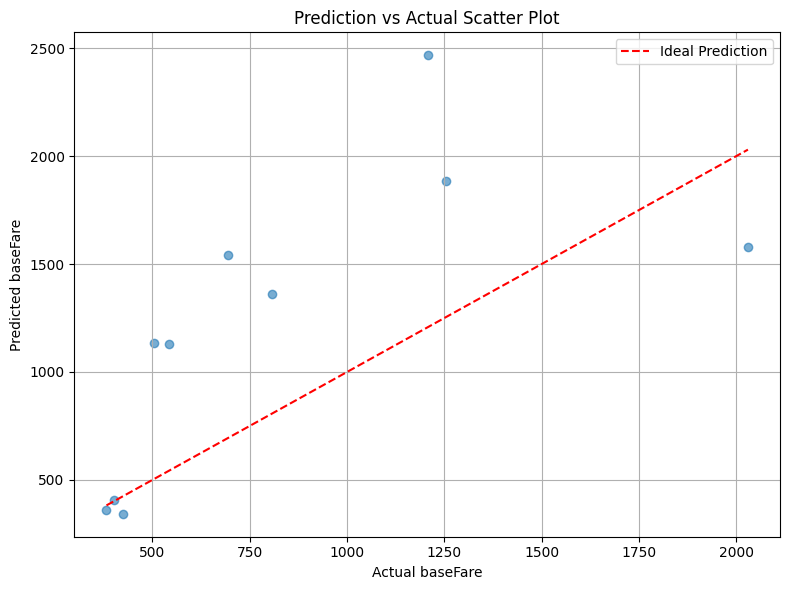

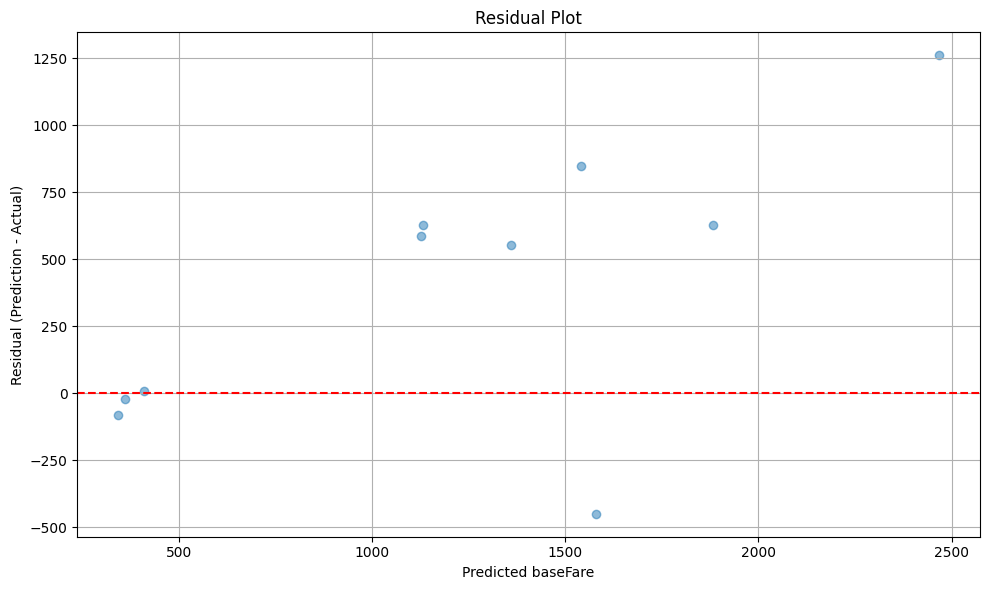

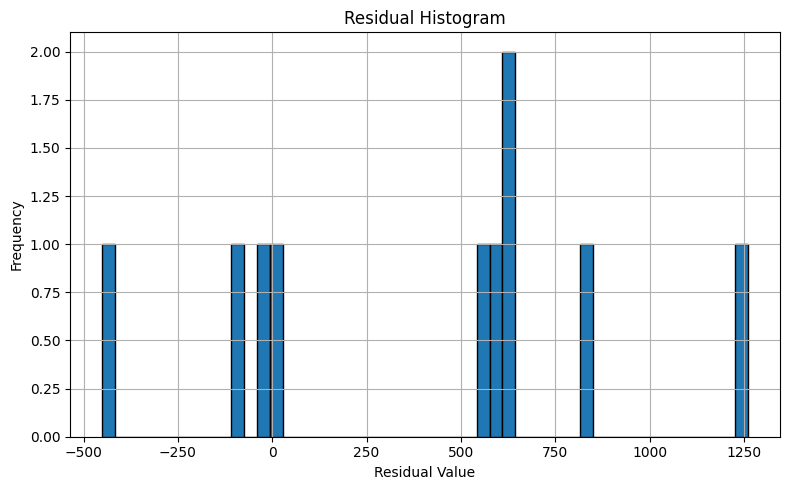

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.metrics import mean_squared_error, r2_score

# 학습 당시 컬럼 순서
feature_columns = [
    'isBasicEconomy', 'isNonStop', 'seatsRemaining', 'totalTravelDistance',
    'cpi', 'ppi', 'unemployment_rate', 'travelDurationMinutes',
    'start_temp', 'start_feelslike', 'start_humidity', 'start_precip',
    'start_windgust', 'start_windspeed', 'start_cloudcover', 'start_visibility',
    'start_uvindex', 'departure_hour', 'hour_0~6', 'hour_6~12',
    'hour_12~18', 'hour_18~24', 'days_before_departure', 'flightMonth',
    'flightDayType_weekend', 'cabin_score', 'stop_count', 'event_day',
    'oil_price', 'airline_score', 'destin_temp', 'destin_feelslike',
    'destin_humidity', 'destin_precip', 'destin_windgust', 'destin_windspeed',
    'destin_cloudcover', 'destin_visibility', 'destin_uvindex', 'baseFare'
]

# MAPE 정의
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    epsilon = 1e-8  # 0 나눗셈 방지
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

# 1. 예측할 CSV 데이터 불러오기
test_df = pd.read_csv('test_6_17.csv')
test_df = test_df[feature_columns]  # 학습 데이터와 동일한 컬럼 정렬

# 2. 모델 불러오기
model = CatBoostRegressor()
model.load_model('catboost_model.cbm')

# 3. Box-Cox 변환 전처리
test_df_boxcox = test_df[test_df['baseFare'] > 0].copy()

# 학습 시 사용한 fitted_lambda 고정
fitted_lambda = 0.396
test_df_boxcox['boxcox_baseFare'] = boxcox(test_df_boxcox['baseFare'], lmbda=fitted_lambda)

# 4. 예측
X_test = test_df_boxcox.drop(columns=['baseFare', 'boxcox_baseFare'])
y_pred_boxcox = model.predict(X_test)

# 5. 예측값 역변환 및 저장
test_df_boxcox['prediction'] = inv_boxcox(y_pred_boxcox, fitted_lambda)

# 2022년과 2025년 CPI 값
cpi_2022 = 292.66
cpi_2025 = 321.47

# 6. 평가
y_true = test_df_boxcox['baseFare'].values
# 2022년 기준 예측값
y_pred_2022 = test_df_boxcox['prediction'].values
# 2025년 기준으로 환산
y_pred_2025 = y_pred_2022 * (cpi_2025 / cpi_2022)

# DataFrame에 새 컬럼으로 저장
test_df_boxcox['prediction'] = y_pred_2025
y_pred = test_df_boxcox['prediction'].values



mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print("예측 결과 일부:")
print(test_df_boxcox[['baseFare', 'prediction']].head())

print(f"\n 성능 평가 (역변환 후 실제 단위 기준):")
print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")

# 7. 시각화
plt.figure(figsize=(8, 6))
plt.scatter(test_df_boxcox['baseFare'], test_df_boxcox['prediction'], alpha=0.6)
plt.plot([test_df_boxcox['baseFare'].min(), test_df_boxcox['baseFare'].max()],
         [test_df_boxcox['baseFare'].min(), test_df_boxcox['baseFare'].max()],
         color='red', linestyle='--', label='Ideal Prediction')
plt.xlabel('Actual baseFare')
plt.ylabel('Predicted baseFare')
plt.title('Prediction vs Actual Scatter Plot')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

residuals = test_df_boxcox['prediction'] - test_df_boxcox['baseFare']

plt.figure(figsize=(10, 6))
plt.scatter(test_df_boxcox['prediction'], residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted baseFare")
plt.ylabel("Residual (Prediction - Actual)")
plt.title("Residual Plot")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, edgecolor='black')
plt.title("Residual Histogram")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


### 성능 향상 방법 탐구 결과 =  고가 항공권(6~10번째 데이터)의 cabin_score을 2로 설정

예측 결과 일부:
   baseFare   prediction
0       425   343.046779
1      2030  1579.468996
2       382   360.785616
3       401   408.744950
4       543  1127.423843

 성능 평가 (역변환 후 실제 단위 기준):
MSE (Mean Squared Error): 65239.74
R² Score: 0.7408
MAPE (Mean Absolute Percentage Error): 24.71%


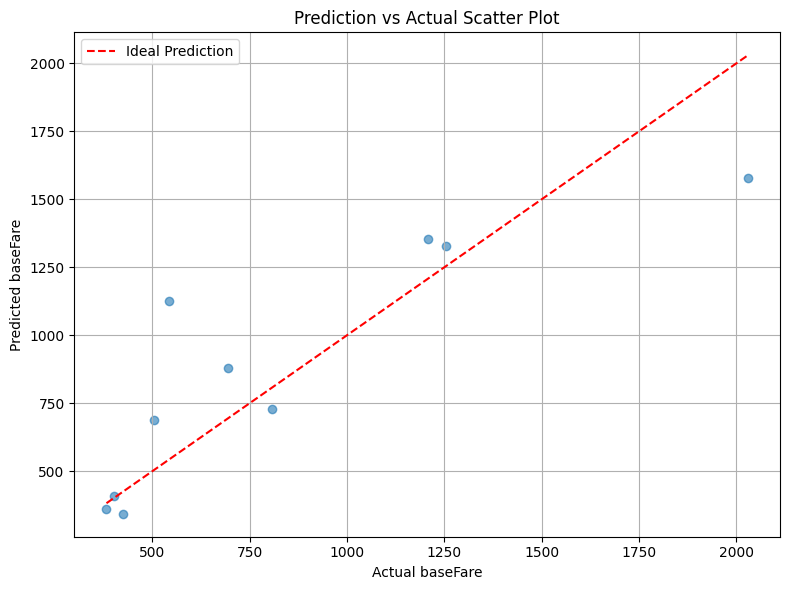

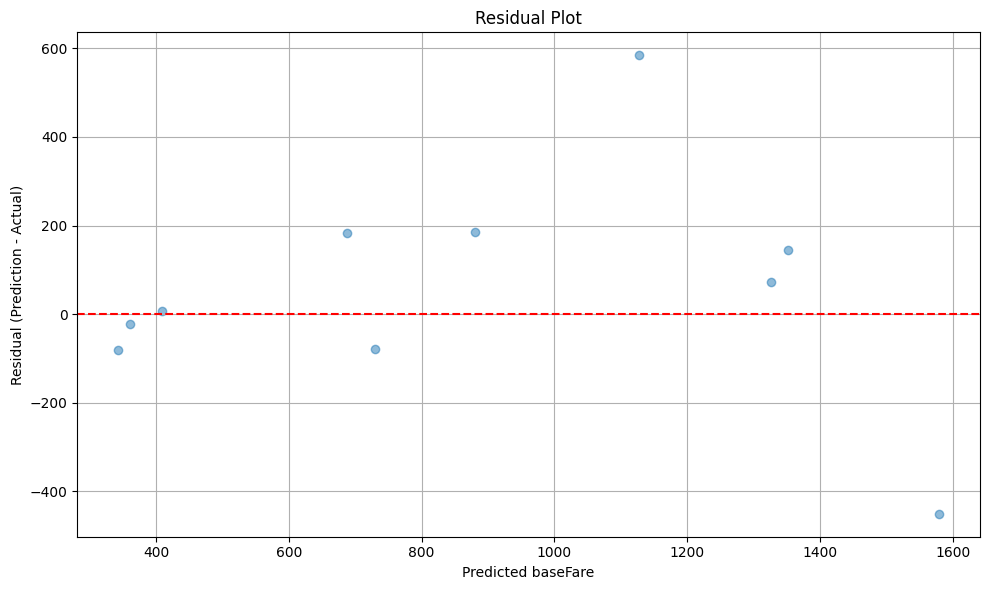

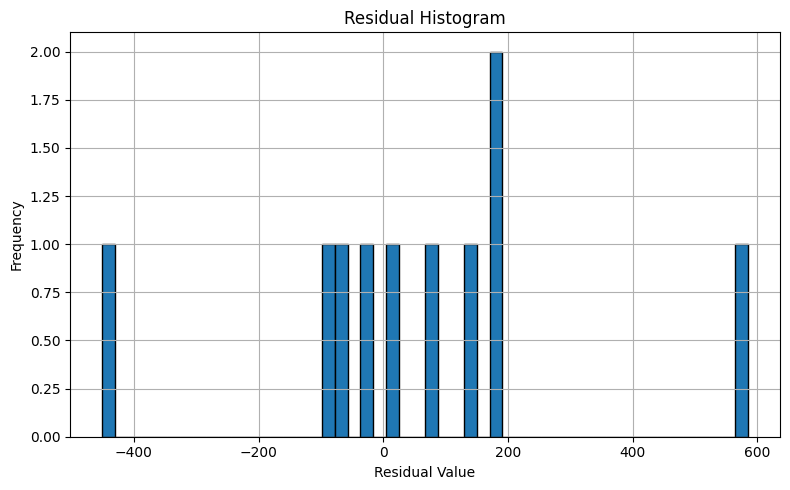

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.metrics import mean_squared_error, r2_score

# 학습 당시 컬럼 순서
feature_columns = [
    'isBasicEconomy', 'isNonStop', 'seatsRemaining', 'totalTravelDistance',
    'cpi', 'ppi', 'unemployment_rate', 'travelDurationMinutes',
    'start_temp', 'start_feelslike', 'start_humidity', 'start_precip',
    'start_windgust', 'start_windspeed', 'start_cloudcover', 'start_visibility',
    'start_uvindex', 'departure_hour', 'hour_0~6', 'hour_6~12',
    'hour_12~18', 'hour_18~24', 'days_before_departure', 'flightMonth',
    'flightDayType_weekend', 'cabin_score', 'stop_count', 'event_day',
    'oil_price', 'airline_score', 'destin_temp', 'destin_feelslike',
    'destin_humidity', 'destin_precip', 'destin_windgust', 'destin_windspeed',
    'destin_cloudcover', 'destin_visibility', 'destin_uvindex', 'baseFare'
]

# MAPE 정의
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    epsilon = 1e-8  # 0 나눗셈 방지
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

# 1. 예측할 CSV 데이터 불러오기
test_df = pd.read_csv('test_6_17.csv')
test_df = test_df[feature_columns]  # 학습 데이터와 동일한 컬럼 정렬
# 6~9번째 행의 cabin_score를 2로 설정
test_df.loc[5:10, 'cabin_score'] = 2

# 2. 모델 불러오기
model = CatBoostRegressor()
model.load_model('catboost_model.cbm')

# 3. Box-Cox 변환 전처리
test_df_boxcox = test_df[test_df['baseFare'] > 0].copy()

# 학습 시 사용한 fitted_lambda 고정
fitted_lambda = 0.396
test_df_boxcox['boxcox_baseFare'] = boxcox(test_df_boxcox['baseFare'], lmbda=fitted_lambda)

# 4. 예측
X_test = test_df_boxcox.drop(columns=['baseFare', 'boxcox_baseFare'])
y_pred_boxcox = model.predict(X_test)

# 5. 예측값 역변환 및 저장
test_df_boxcox['prediction'] = inv_boxcox(y_pred_boxcox, fitted_lambda)

# 2022년과 2025년 CPI 값
cpi_2022 = 292.66
cpi_2025 = 321.47

# 6. 평가
y_true = test_df_boxcox['baseFare'].values
# 2022년 기준 예측값
y_pred_2022 = test_df_boxcox['prediction'].values
# 2025년 기준으로 환산
y_pred_2025 = y_pred_2022 * (cpi_2025 / cpi_2022)

# DataFrame에 새 컬럼으로 저장
test_df_boxcox['prediction'] = y_pred_2025
y_pred = test_df_boxcox['prediction'].values



mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print("예측 결과 일부:")
print(test_df_boxcox[['baseFare', 'prediction']].head())

print(f"\n 성능 평가 (역변환 후 실제 단위 기준):")
print(f"MSE (Mean Squared Error): {mse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")

# 7. 시각화
plt.figure(figsize=(8, 6))
plt.scatter(test_df_boxcox['baseFare'], test_df_boxcox['prediction'], alpha=0.6)
plt.plot([test_df_boxcox['baseFare'].min(), test_df_boxcox['baseFare'].max()],
         [test_df_boxcox['baseFare'].min(), test_df_boxcox['baseFare'].max()],
         color='red', linestyle='--', label='Ideal Prediction')
plt.xlabel('Actual baseFare')
plt.ylabel('Predicted baseFare')
plt.title('Prediction vs Actual Scatter Plot')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

residuals = test_df_boxcox['prediction'] - test_df_boxcox['baseFare']

plt.figure(figsize=(10, 6))
plt.scatter(test_df_boxcox['prediction'], residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted baseFare")
plt.ylabel("Residual (Prediction - Actual)")
plt.title("Residual Plot")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, edgecolor='black')
plt.title("Residual Histogram")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


### 학습 당시 first, business 등 고가 항공권의 경우 과도하게 높은 가격의 이상치, 분포로 인해 고가 항공의 경우 예측 결과가 크게 나온다.